In [1]:
import numpy as np
from pathlib import Path
import pandas as pd

In [2]:
saved_dir = Path(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD")

train_dfs = pd.read_pickle(saved_dir / "train_dfs.pkl")
test_dfs = pd.read_pickle(saved_dir / "test_dfs.pkl")

print("Reloaded train_dfs and test_dfs from saved_data/")
print("Train dfs:", len(train_dfs))
print("Test dfs:", len(test_dfs))
print("Train sizes:", [len(df) for df in train_dfs])
print("Test sizes:", [len(df) for df in test_dfs])

Reloaded train_dfs and test_dfs from saved_data/
Train dfs: 28
Test dfs: 28
Train sizes: [41580, 39911, 42657, 40945, 25197, 24186, 8058, 8024, 49098, 47143, 62576, 60064, 121688, 116802, 13400, 12862, 47249, 45352, 48501, 46554, 39720, 38128, 73526, 70575, 46872, 44992, 2393018, 850900]
Test sizes: [10394, 9977, 10664, 10236, 6299, 6046, 2014, 2006, 12274, 11785, 15644, 15016, 30421, 29200, 3349, 3215, 11812, 11338, 12125, 11638, 9930, 9531, 18381, 17643, 11718, 11247, 598254, 212724]


In [3]:
def data_to_uint8_array(data):
    if isinstance(data, bytes):
        arr = np.frombuffer(data, dtype=np.uint8)
    elif isinstance(data, str):
        s = data.strip()
        if s.startswith(("0x", "0X")):
            s = s[2:]
        if any(ch in s for ch in (" ", "-", ":", ",")):
            parts = [tok for tok in s.replace("-", " ").replace(":", " ").replace(",", " ").split() if tok]
            if all(len(tok) == 2 for tok in parts):
                arr = np.array([int(tok, 16) for tok in parts], dtype=np.uint8)
            else:
                arr = np.frombuffer(bytes.fromhex("".join(parts)), dtype=np.uint8)
        else:
            arr = np.frombuffer(bytes.fromhex(s), dtype=np.uint8)
    elif isinstance(data, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(data, dtype=np.uint8).flatten()
    elif isinstance(data, int):
        arr = np.frombuffer(data.to_bytes(8, byteorder="big", signed=False), dtype=np.uint8)
    else:
        raise TypeError(f"Unsupported Data type: {type(data)}")

    if arr.size < 8:
        arr = np.pad(arr, (0, 8 - arr.size), constant_values=0)
    elif arr.size > 8:
        arr = arr[:8]

    return arr

def sliding_windows_from_dfs(dfs, data_col="Data", window_size=32, step=2):
    windows = []
    next_values = []

    for df in dfs:
        values = df[data_col].tolist()
        byte_rows = np.stack([data_to_uint8_array(value) for value in values])

        for start in range(0, len(byte_rows) - window_size, step):
            end = start + window_size
            windows.append(byte_rows[start:end])
            next_values.append(byte_rows[end])

    return np.array(windows, dtype=np.uint8), np.array(next_values, dtype=np.uint8)

train_windows, train_next = sliding_windows_from_dfs(train_dfs, data_col="Data")
test_windows, test_next = sliding_windows_from_dfs(test_dfs, data_col="Data")

print("train_windows shape:", train_windows[0])
print("test_windows shape:", test_windows[0])

train_windows shape: [[137  53   0  11   9 255 236 128]
 [  0   0   0   0   0   0   0   0]
 [ 10 119   4  96 241   3   7   0]
 [  0   6  80   0  12  67  23 208]
 [144   0  64 223  64  63 111  96]
 [  0  16 248 164 225  46   0 160]
 [  0   0  24   0   0   0   0   0]
 [ 20 234  86   0   0   0  88   0]
 [  0   0   0   0   0   0   0   0]
 [128   0   0   0   0   0   0   0]
 [ 24   2   2   0   0   0   0   0]
 [ 32  82 214   2   8   9 117  96]
 [ 17  52  10  79  71  10  74   8]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [154  12   1   2   4 177   2  64]
 [  0   0   4  32 172   1   0  32]
 [  0   8   8   3 231 216   0   0]
 [ 78  32   3 161 132 191 143 247]
 [223 127 208   0 123 192   0  28]
 [126 157 200   2   1  71 206  56]
 [  0   0   0   6 124   7 250 144]
 [  1 104  96 172 156 204  92 240]
 [  2 164   2 156   2 156   2 155]
 [132   0  32   0 231 128 193  77]
 [247   0   0   2 212   0  16   0]
 [  0   0   0   0   0   0   0   4]
 [ 32  16   0   0   0   1 225 128]

In [4]:
def sliding_windows_id_onehot_sums(dfs, id_onehot_col="ID_onehot", window_size=32, step=2):
    window_sums = []

    for df in dfs:
        if id_onehot_col not in df.columns:
            raise ValueError(f"Column {id_onehot_col!r} not found in DataFrame")

        id_onehot_arr = np.stack(df[id_onehot_col].tolist())

        if id_onehot_arr.ndim != 3 or id_onehot_arr.shape[1:] != (22, 8):
            raise ValueError(
                f"Expected {id_onehot_col} items to have shape (22, 8), "
                f"but got {id_onehot_arr.shape[1:]} from one DataFrame"
            )

        for start in range(0, len(id_onehot_arr) - window_size, step):
            window = id_onehot_arr[start:start + window_size]
            window_sums.append(window.sum(axis=0, dtype=np.uint16))

    return np.array(window_sums, dtype=np.uint16)


train_id_onehot_sums = sliding_windows_id_onehot_sums(train_dfs)
test_id_onehot_sums = sliding_windows_id_onehot_sums(test_dfs)



In [5]:
print("train_id_onehot_sums shape:", train_id_onehot_sums[0])
print("test_id_onehot_sums shape:", test_id_onehot_sums[0])

train_id_onehot_sums shape: [[1 1 1 1 1 1 1 1]
 [4 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
test_id_onehot_sums shape: [[1 1 1 1 1 2 0 0]
 [2 0 0 2 0 0 0 1]
 [1 1 1 1 1 4 0 1]
 [0 1 0 0 0 1 0 0]
 [0 0 0 0 1 1 1 0]
 [0 0 0 1 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [6]:
train_windows_combined = np.concatenate(
    [train_windows.astype(np.uint16), train_id_onehot_sums.astype(np.uint16)], axis=1
)
test_windows_combined = np.concatenate(
    [test_windows.astype(np.uint16), test_id_onehot_sums.astype(np.uint16)], axis=1
)

print("train_windows_combined shape:", train_windows_combined.shape)
print("test_windows_combined shape:", test_windows_combined.shape)

train_windows_combined shape: (2229345, 54, 8)
test_windows_combined shape: (556998, 54, 8)


In [7]:
train_windows_combined[0]

array([[137,  53,   0,  11,   9, 255, 236, 128],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [ 10, 119,   4,  96, 241,   3,   7,   0],
       [  0,   6,  80,   0,  12,  67,  23, 208],
       [144,   0,  64, 223,  64,  63, 111,  96],
       [  0,  16, 248, 164, 225,  46,   0, 160],
       [  0,   0,  24,   0,   0,   0,   0,   0],
       [ 20, 234,  86,   0,   0,   0,  88,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [128,   0,   0,   0,   0,   0,   0,   0],
       [ 24,   2,   2,   0,   0,   0,   0,   0],
       [ 32,  82, 214,   2,   8,   9, 117,  96],
       [ 17,  52,  10,  79,  71,  10,  74,   8],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0],
       [154,  12,   1,   2,   4, 177,   2,  64],
       [  0,   0,   4,  32, 172,   1,   0,  32],
       [  0,   8,   8,   3, 231, 216,   0,   0],
       [ 78,  32,   3, 161, 132, 191, 143, 247],
       [223, 127, 208,   0, 123, 192,   0,  28],
       [126, 157, 20

In [8]:
def sliding_windows_attack_labels(dfs, attack_col="Attack", window_size=32, step=2):
    windows_labels = []
    
    for df in dfs:
        attacks = df[attack_col].tolist()
        
        for start in range(0, len(attacks) - window_size, step):
            window_slice = attacks[start:start + window_size]
            
            # If 'T' is in the window, label is 'T', otherwise 'R'
            label = 'T' if 'T' in window_slice else 'R'
            windows_labels.append(label)
    
    return np.array(windows_labels, dtype=object)

attack_labels_train = sliding_windows_attack_labels(train_dfs)
attack_labels_test = sliding_windows_attack_labels(test_dfs)

print("attack_labels_train shape:", attack_labels_train.shape)
print("attack_labels_test shape:", attack_labels_test.shape)
print("Sample labels (first 20):", attack_labels_train[:20])

attack_labels_train shape: (2229345,)
attack_labels_test shape: (556998,)
Sample labels (first 20): ['R' 'R' 'R' 'R' 'R' 'R' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T'
 'T' 'T']


In [9]:
windows = train_windows_combined
windows_test = test_windows_combined
windowed_labels = attack_labels_train
windowed_labels_test = attack_labels_test

In [10]:
t_positions = np.flatnonzero(windowed_labels == 'T')
print(f"Found {t_positions.size} 'T' labels in windowed_labels")
if t_positions.size:
    print("First positions:", t_positions[:20].tolist())

Found 577390 'T' labels in windowed_labels
First positions: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


In [11]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]]


In [12]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])

[[0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]]


In [15]:
import tensorflow as tf
import tensorflow as tf

from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(54, 8, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

In [16]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(windows, attack_onehot, epochs=5, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 88s 97ms/step - accuracy: 0.8459 - loss: 0.4234 - val_accuracy: 0.9076 - val_loss: 0.2243
Epoch 2/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 87s 98ms/step - accuracy: 0.9702 - loss: 0.0793 - val_accuracy: 0.9302 - val_loss: 0.1739
Epoch 3/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 86s 97ms/step - accuracy: 0.9861 - loss: 0.0384 - val_accuracy: 0.9545 - val_loss: 0.1180
Epoch 4/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 86s 97ms/step - accuracy: 0.9916 - loss: 0.0233 - val_accuracy: 0.9807 - val_loss: 0.0518
Epoch 5/5
892/892 ━━━━━━━━━━━━━━━━━━━━ 91s 102ms/step - accuracy: 0.9944 - loss: 0.0157 - val_accuracy: 0.9732 - val_loss: 0.0720


In [17]:
loss, accuracy = model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.1198
Test accuracy: 0.9575


In [18]:
label_map = np.array(['R', 'T'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(windows_test))
print(recovered_labels[:20])

17407/17407 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step
['T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T' 'T'
 'T' 'T']


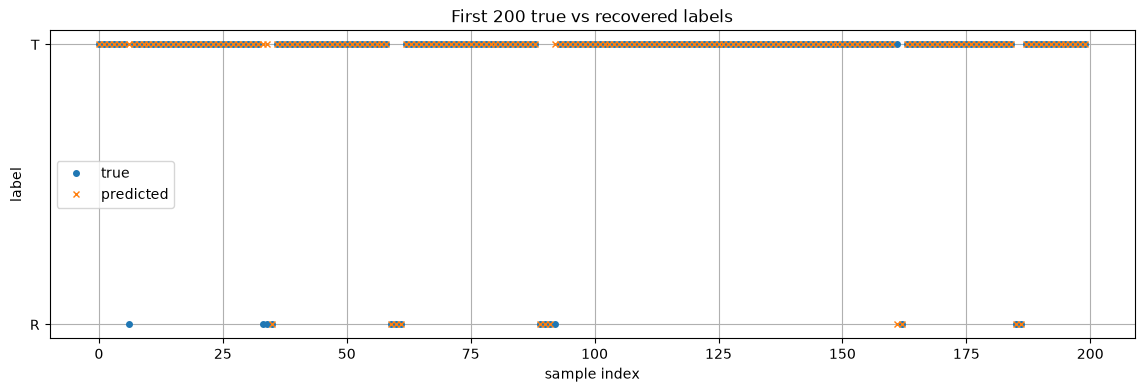

In [19]:
true_labels = np.array(onehot_to_labels(attack_onehot_test))
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

# Predictions
y_pred_probs = model.predict(windows_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(attack_onehot_test)

# Overall metrics
accuracy = accuracy_score(y_true, y_pred)
weighted_precision = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_recall = recall_score(
    y_true, y_pred, average="weighted", zero_division=0
)
weighted_f1 = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")
print(f"Weighted recall: {weighted_recall:.4f}")
print(f"Weighted F1 score: {weighted_f1:.4f}")
print()

# Classification report
print("Classification report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=label_map,
        target_names=label_map,
        zero_division=0,
        digits=2,        # Matches the example formatting
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=label_map)

print("Confusion matrix:")
print(pd.DataFrame(cm, index=label_map, columns=label_map))
print()

# Calculate FPR and FNR
tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(
    fps,
    fps + tns,
    out=np.zeros_like(fps, dtype=float),
    where=(fps + tns) != 0,
)

fnr = np.divide(
    fns,
    fns + tps,
    out=np.zeros_like(fns, dtype=float),
    where=(fns + tps) != 0,
)

print("False positive rate per class:")
for label, rate in zip(label_map, fpr):
    print(f"  {label}: {rate:.4f}")

print()
print("False negative rate per class:")
for label, rate in zip(label_map, fnr):
    print(f"  {label}: {rate:.4f}")

17407/17407 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step
Accuracy: 0.9575
Weighted precision: 0.9614
Weighted recall: 0.9575
Weighted F1 score: 0.9582

Classification report:
              precision    recall  f1-score   support

           R       0.99      0.95      0.97    412496
           T       0.87      0.98      0.92    144502

    accuracy                           0.96    556998
   macro avg       0.93      0.97      0.95    556998
weighted avg       0.96      0.96      0.96    556998

Confusion matrix:
        R       T
R  391537   20959
T    2738  141764

False positive rate per class:
  R: 0.0189
  T: 0.0508

False negative rate per class:
  R: 0.0508
  T: 0.0189


In [ ]:
"""import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model_2.h5"))
print("Saved model to saved_models/HCRL_model_2.h5")"""
exit()
hello()

NameError: name 'hello' is not defined

: 

In [ ]:
import numpy as np

windows = np.expand_dims(windows, axis=-1)
windows_test = np.expand_dims(windows_test, axis=-1)

def representative_dataset():
    for i in range(100):
        yield [windows[i:i+1].astype(np.float32)]

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("cnn_int8_2.tflite", "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh\assets


INFO:tensorflow:Assets written to: C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh\assets


Saved artifact at 'C:\Users\nb0801\AppData\Local\Temp\tmp_wfzlxuh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 10, 1), dtype=tf.float32, name='keras_tensor_22')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  2128368032016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368032592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368029904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368032208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368033168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2128368031056: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


: 

In [ ]:
interpreter = tf.lite.Interpreter(
    model_path="cnn_int8_2.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
sample = windows[0:1].astype(np.float32)

scale, zero_point = input_details[0]["quantization"]

sample_int8 = (sample / scale + zero_point).astype(np.int8)

In [ ]:
import tensorflow as tf
import numpy as np
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

# ----------------------------
# Load TFLite model
# ----------------------------

interpreter = tf.lite.Interpreter(model_path="cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero = input_details[0]["quantization"]
output_scale, output_zero = output_details[0]["quantization"]

# ----------------------------
# Run inference
# ----------------------------

predictions = []

start = time.perf_counter()

for sample in windows_test:

    sample = np.expand_dims(sample, axis=0).astype(np.float32)

    # Quantize input if needed
    if input_details[0]["dtype"] == np.int8:
        sample = (sample / input_scale + input_zero).astype(np.int8)

    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])

    # Dequantize output
    if output_details[0]["dtype"] == np.int8:
        output = (output.astype(np.float32) - output_zero) * output_scale

    predictions.append(np.argmax(output))

end = time.perf_counter()

print(f"Average inference time: {(end-start)/len(windows_test)*1000:.3f} ms")

predictions = np.array(predictions)

# ----------------------------
# Convert one-hot labels
# ----------------------------

y_true = np.argmax(attack_onehot_test, axis=1)

# ----------------------------
# Accuracy
# ----------------------------

accuracy = accuracy_score(y_true, predictions)

print(f"\nTest accuracy: {accuracy:.4f}")

# ----------------------------
# Classification report
# ----------------------------

target_names = ["R","D","F","S"]

print("\nClassification report:")
print(
    classification_report(
        y_true,
        predictions,
        target_names=target_names,
        digits=4
    )
)

# ----------------------------
# Confusion Matrix
# ----------------------------

cm = confusion_matrix(y_true, predictions)

print("\nConfusion matrix:")
print("\tR\tD\tF\tS")
print(cm)

# ----------------------------
# Per-class metrics
# ----------------------------

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    predictions
)

for i, cls in enumerate(target_names):

    FP = cm[:, i].sum() - cm[i, i]
    FN = cm[i, :].sum() - cm[i, i]
    TP = cm[i, i]
    TN = cm.sum() - (TP + FP + FN)

    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    print(
        f"{cls}: "
        f"precision={precision[i]:.4f}, "
        f"recall={recall[i]:.4f}, "
        f"f1={f1[i]:.4f}, "
        f"false positive rate={fpr:.4f}, "
        f"false negative rate={fnr:.4f}"
    )

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Average inference time: 0.061 ms

Test accuracy: 0.9995

Classification report:
              precision    recall  f1-score   support

           R     0.9992    0.9999    0.9995    927753
           D     0.9998    0.9983    0.9991    147176
           F     0.9999    0.9985    0.9992    187436
           S     0.9998    0.9995    0.9996    493389

    accuracy                         0.9995   1755754
   macro avg     0.9997    0.9990    0.9994   1755754
weighted avg     0.9995    0.9995    0.9995   1755754


Confusion matrix:
	R	D	F	S
[[927649     12     17     75]
 [   246 146925      3      2]
 [   268     11 187157      0]
 [   266      2      1 493120]]
R: precision=0.9992, recall=0.9999, f1=0.9995, false positive rate=0.0009, false negative rate=0.0001
D: precision=0.9998, recall=0.9983, f1=0.9991, false positive rate=0.0000, false negative rate=0.0017
F: precision=0.9999, recall=0.9985, f1=0.9992, false positive rate=0.0000, false negative rate=0.0015
S: precision=0.9998, recal

In [ ]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\CNN\saved_models\cnn_int8_2.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded successfully")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

Model loaded successfully
Input shape: [ 1 32 10  1]
Output shape: [1 4]


NameError: name 'int_windowed_id_data_test' is not defined